<a href="https://www.kaggle.com/code/anlceyhanyeni/german-ebay-used-cars-price-prediction?scriptVersionId=320151362" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Imports

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from catboost import CatBoostRegressor

# Loading the Data

# What is the data?
Dataset of used cars from eBay Kleinanzeigen, a classifieds section of the German eBay website.

# What will we do?

We will clean the data, imput or remove for missing values, make necessary changes then try to predict a car's price

In [2]:
autos = pd.read_csv('/kaggle/input/datasets/sijovm/used-cars-data-from-ebay-kleinanzeigen/autos.csv', encoding='latin1')

In [3]:
autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   dateCrawled          371528 non-null  object
 1   name                 371528 non-null  object
 2   seller               371528 non-null  object
 3   offerType            371528 non-null  object
 4   price                371528 non-null  int64 
 5   abtest               371528 non-null  object
 6   vehicleType          333659 non-null  object
 7   yearOfRegistration   371528 non-null  int64 
 8   gearbox              351319 non-null  object
 9   powerPS              371528 non-null  int64 
 10  model                351044 non-null  object
 11  kilometer            371528 non-null  int64 
 12  monthOfRegistration  371528 non-null  int64 
 13  fuelType             338142 non-null  object
 14  brand                371528 non-null  object
 15  notRepairedDamage    299468 non-nu

We realize columns below have null values, especially, notRepairedDamage
* vehicleType
* gearbox
* model
* fuelType
* notRepairedDamage    

In [4]:
autos.head()

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,0,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


The dataset has 19 columns: 
* dateCrawled - When the ad was first crawled. All field-values are taken from this date.
* name - Name of the car.
* seller - Whether the seller is private or a dealer.
* offerType - The type of listing.
* price - The listed selling price of the car.
* abtest - Whether the listing is included in an A/B test.
* vehicleType - The type of vehicle.
* yearOfRegistration - The year in which the car was first registered.
* gearbox - The type of transmission.
* powerPS - The power of the car in PS.
* model - The car model name.
* odometer - How many kilometers the car has driven.
* monthOfRegistration - The month in which the car was first registered.
* fuelType - What type of fuel the car uses.
* brand - The brand of the car.
* notRepairedDamage - If the car has a damage which is not yet repaired.
* dateCreated - The date the eBay listing was created.
* nrOfPictures - The number of pictures in the ad.
* postalCode - The postal code for the location of the vehicle.
* lastSeen - When the crawler saw this ad last online.



In [5]:
autos.columns

Index(['dateCrawled', 'name', 'seller', 'offerType', 'price', 'abtest',
       'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS', 'model',
       'kilometer', 'monthOfRegistration', 'fuelType', 'brand',
       'notRepairedDamage', 'dateCreated', 'nrOfPictures', 'postalCode',
       'lastSeen'],
      dtype='object')

In [6]:
autos = autos.rename(columns = {
    "dateCrawled":"crawl_date",
    "offerType":"offer_type",
    "vehicleType":"vehicle_type",
    "yearOfRegistration":"registration_year",
    "powerPS":"horsepower",
    "monthOfRegistration":"registration_month",
    "fuelType":"fuel_type",
    "notRepairedDamage":"unrepaired_damage",
    "dateCreated":"ad_created",
    "nrOfPictures":"picture_numbers",
    "postalCode":"postal_code",
    "lastSeen":"last_seen"
})


**Renamed columns for better readability, also more standardized for python**

# Exploratory Data Analysis (EDA)

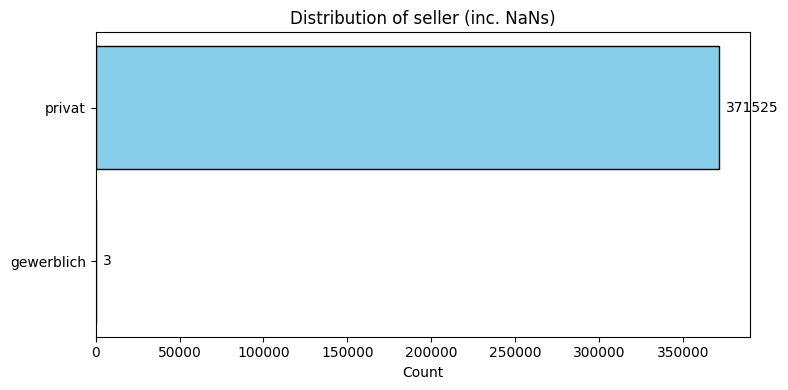

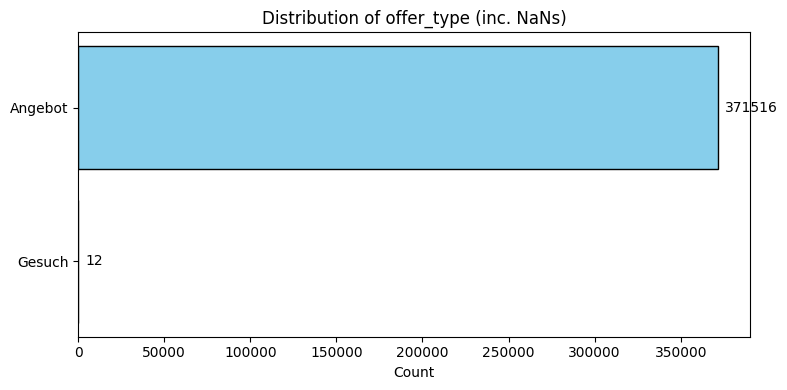

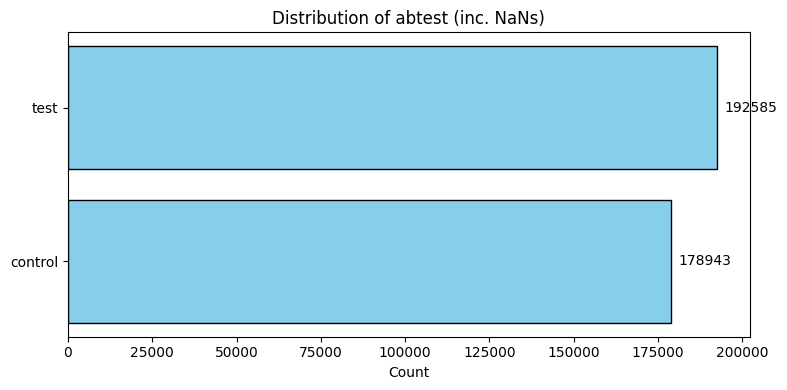

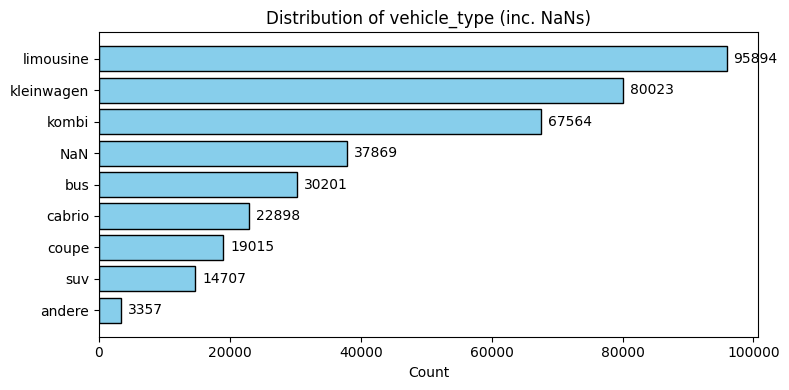

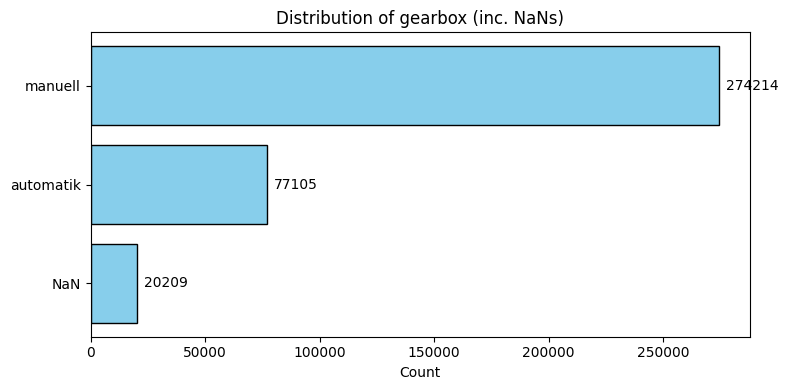

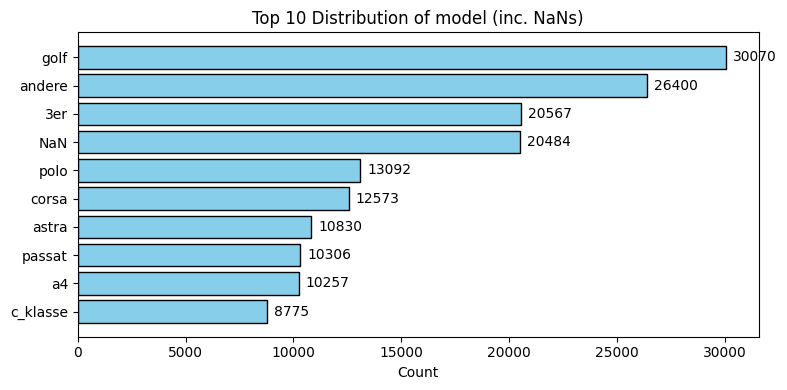

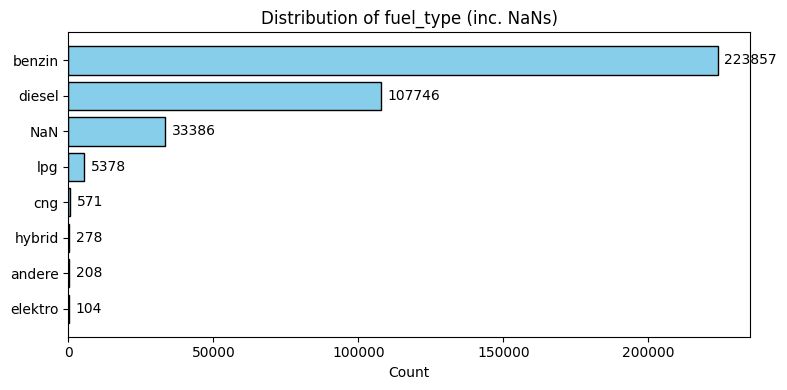

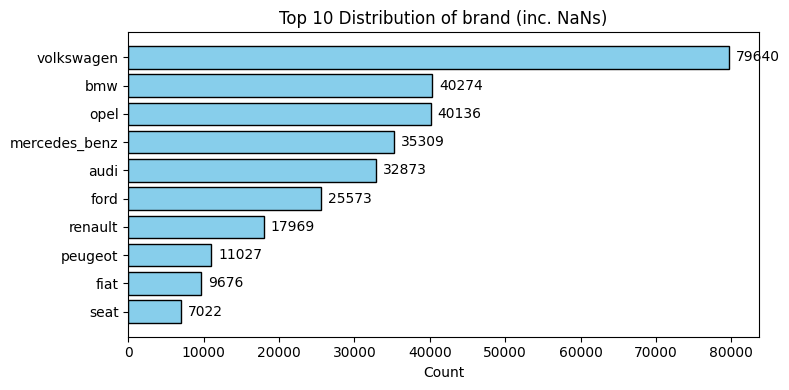

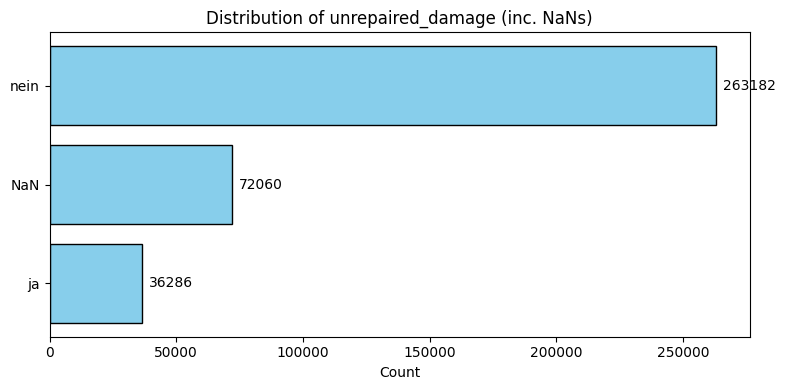

In [7]:

columns = ['seller', 'offer_type', 'abtest', 'vehicle_type', 'gearbox', 'model', 'fuel_type', 'brand', 'unrepaired_damage']

for col in columns:
    
    counts = autos[col].value_counts(dropna=False)
    counts.index = counts.index.fillna('NaN')
    
    top_10 = counts.head(10)
    
    top_10_sorted = top_10.sort_values(ascending=True)
    
    plt.figure(figsize=(8, 4))
    
    bars = plt.barh(top_10_sorted.index, top_10_sorted.values, color='skyblue', edgecolor='black')
    plt.bar_label(bars, padding=5)
    
    if len(counts) > 10:
        plt.title(f'Top 10 Distribution of {col} (inc. NaNs)')
    else:
        plt.title(f'Distribution of {col} (inc. NaNs)')
        
    plt.xlabel('Count')
    plt.tight_layout()
    plt.show()

# Some inferences

Almost all of the sellers are private sellers

According to a/b testing we see slight leaning to bigger percentage of test cars being sold

* Angebot:The car is being offered on the market
* Gesuch: A price for certain car is being offered on the market
* We can see almost every record is of a sale and not a search

Manual gearboxes are higher percentage than automatics

* limousine : sedan
* kleinwagen : small car / B-segment
* kombi:station wagon/crew van
* We see a LOT of missing values in vehicle_type

Golf is top model type, with notable amounts of andere:other and NaN values

Cars use mostly benzin and diesel, again lots of missing values in fuel_type

Brand with most cars is volkswagen followed by bmw, opel and mercedes-benz

Majority of the damages are repaired, some are not, but there are 72k null values which is suspicious

**Rough age of the cars:**

In [8]:
# Extracting the first 4 characters of 'crawl_date'
crawl_year = autos['crawl_date'].str[:4].astype(int)

# Creating new column with subtracted registration years
autos['age_years'] = crawl_year - autos['registration_year']


In [9]:
cleaned_autos = autos[
    (autos['price'].between(500, 20000)) &
    (autos['horsepower'].between(50, 500)) &
    (autos['age_years'].between(0, 30))
].copy()

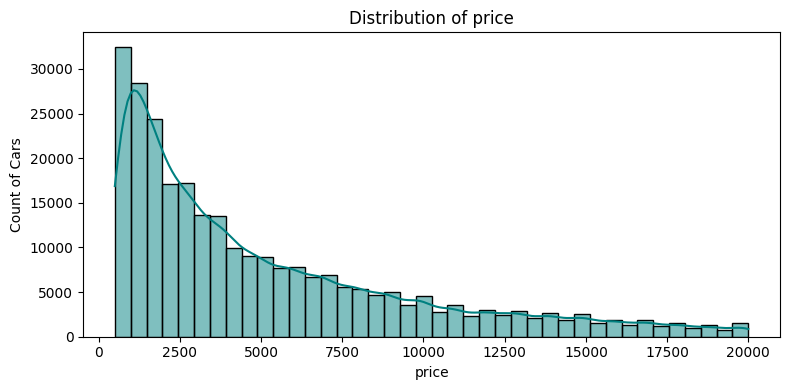

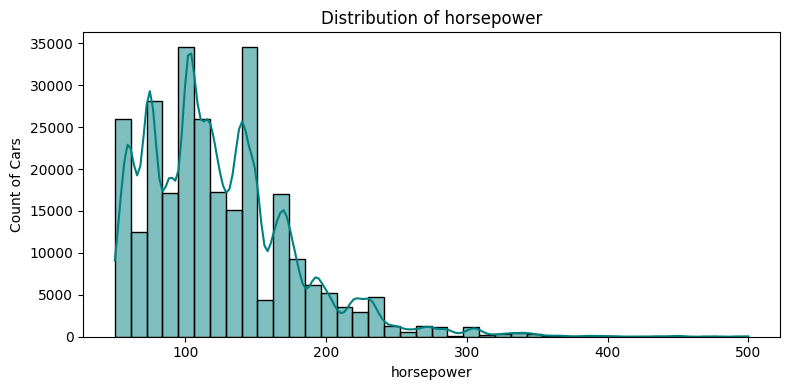

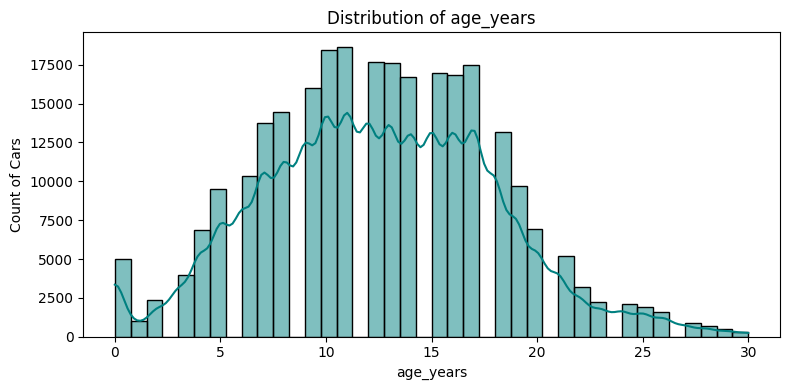

<Figure size 900x400 with 0 Axes>

In [10]:


continuous_features = ['price', 'horsepower', 'age_years']

for col in continuous_features:
    plt.figure(figsize=(8, 4))
    # kde=True overlays a smooth distribution trend line
    sns.histplot(cleaned_autos[col], bins=40, kde=True, color='teal', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count of Cars')
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(9, 4))
km_counts = cleaned_autos['kilometer'].value_counts().sort_index()

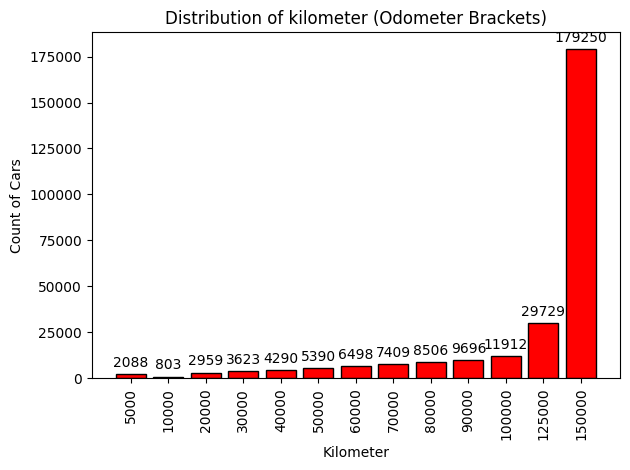

In [11]:
bars = plt.bar(km_counts.index.astype(str), km_counts.values, color='red', edgecolor='black')
plt.bar_label(bars, padding=3, fmt='%d')
plt.title('Distribution of kilometer (Odometer Brackets)')
plt.xlabel('Kilometer')
plt.ylabel('Count of Cars')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Preparing for the model

In [12]:
categorical_cols = ['brand', 'model', 'vehicle_type', 'gearbox', 'fuel_type', 'unrepaired_damage', 'abtest']
numerical_cols = ['horsepower', 'kilometer', 'age_years']

In [13]:
X = cleaned_autos[categorical_cols + numerical_cols].copy()
y = cleaned_autos['price']

In [14]:
for col in categorical_cols:
    X[col] = X[col].fillna('Missing').astype(str)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
reg_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.08,        # Slightly faster learning rate for regression
    depth=6,
    cat_features=categorical_cols,
    loss_function='RMSE',       # Optimize for Root Mean Squared Error
    random_seed=42,
    verbose=100                 # Output progress every 100 iterations
)

In [17]:
reg_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,
    verbose=100
)

0:	learn: 4351.5533403	test: 4341.6854938	best: 4341.6854938 (0)	total: 207ms	remaining: 3m 26s
100:	learn: 1700.8260772	test: 1704.7572536	best: 1704.7572536 (100)	total: 10.3s	remaining: 1m 31s
200:	learn: 1621.5300828	test: 1630.5771748	best: 1630.5771748 (200)	total: 20.6s	remaining: 1m 21s
300:	learn: 1581.7586736	test: 1596.6433158	best: 1596.6433158 (300)	total: 31s	remaining: 1m 12s
400:	learn: 1554.8767305	test: 1574.7898897	best: 1574.7898897 (400)	total: 41.6s	remaining: 1m 2s
500:	learn: 1535.9261904	test: 1560.1508324	best: 1560.1508324 (500)	total: 52.3s	remaining: 52.1s
600:	learn: 1521.4234171	test: 1550.1494458	best: 1550.1494458 (600)	total: 1m 2s	remaining: 41.7s
700:	learn: 1508.4954365	test: 1540.8885852	best: 1540.8885852 (700)	total: 1m 13s	remaining: 31.2s
800:	learn: 1497.8368810	test: 1534.0180598	best: 1534.0017522 (799)	total: 1m 23s	remaining: 20.8s
900:	learn: 1488.7505657	test: 1528.0398772	best: 1528.0398772 (900)	total: 1m 34s	remaining: 10.3s
999:	lear

CatBoostRegressor(cat_features=['brand', 'model', 'vehicle_type', 'gearbox', 'fuel_type', 'unrepaired_damage', 'abtest'], depth=6, iterations=1000, learning_rate=0.08, loss_function='RMSE', random_seed=42, verbose=100)

In [18]:
y_pred = reg_model.predict(X_test)

# Calculate Evaluation Metrics
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n" + "="*50)
print(f"Model Test RMSE: ${rmse:.2f}")
print(f"Model Test R² Score: {r2:.4f}")
print("="*50)


Model Test RMSE: $1521.97
Model Test R² Score: 0.8901


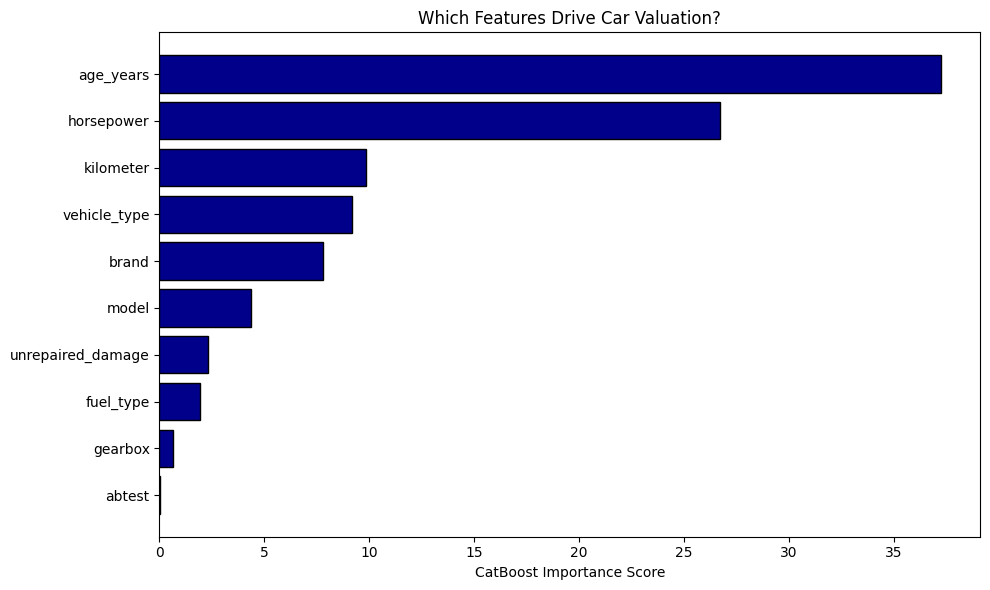

In [19]:
importance = reg_model.get_feature_importance()
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='darkblue', edgecolor='black')
plt.title('Which Features Drive Car Valuation?')
plt.xlabel('CatBoost Importance Score')
plt.tight_layout()
plt.show()